# Shot Analysis and Expected Goals (xG)

This notebook is lesson 5 of the Soccermatics course by David Sumpter.

**Goals:**
- Filter shot events from the Nigeria vs Canada match
- Plot shots on a pitch with outcome indicators
- Understand and visualize xG (expected goals)
- Interpret what xG tells us about shot quality

**Libraries used:** `statsbombpy`, `mplsoccer`, `pandas`, `matplotlib`

In [2]:
#importing libraries
from statsbombpy import sb
import pandas as pd
import matplotlib.pyplot as plt
from mplsoccer import Pitch, VerticalPitch

In [3]:
#Filtering shot events
events = sb.events(match_id=3893790)
shots = events[events['type'] == 'Shot']
shots.shape

(26, 92)

In [4]:
#shot specific columns
shots[['player', 'team', 'location', 'shot_outcome', 'shot_statsbomb_xg', 'shot_technique', 'shot_body_part']].head(10)

,player,team,location,shot_outcome,shot_statsbomb_xg,shot_technique,shot_body_part
2876,Christine Margaret Sinclair,Canada Women's,"[101.1, 35.4]",Off T,0.076098,Normal,Right Foot
2877,Kadeisha Buchanan,Canada Women's,"[107.5, 40.4]",Blocked,0.057931,Volley,Right Foot
2878,Rebecca Quinn,Canada Women's,"[101.4, 45.4]",Blocked,0.028515,Half Volley,Right Foot
2879,Ifeoma Onumonu,Nigeria Women's,"[94.5, 32.1]",Saved,0.028313,Normal,Right Foot
2880,Jordyn Pamela Huitema,Canada Women's,"[110.4, 40.7]",Off T,0.080710,Normal,Head
2881,Julia Angela Grosso,Canada Women's,"[90.4, 35.1]",Blocked,0.012315,Normal,Left Foot
2882,Ifeoma Onumonu,Nigeria Women's,"[100.2, 20.4]",Blocked,0.009077,Normal,Right Foot
2883,Ifeoma Onumonu,Nigeria Women's,"[107.8, 44.9]",Blocked,0.030156,Normal,Head
2884,Deborah Ajibola Abiodun,Nigeria Women's,"[94.5, 31.7]",Off T,0.022633,Normal,Right Foot
2885,Asisat Lamina Oshoala,Nigeria Women's,"[117.3, 25.1]",Wayward,0.073568,Normal,Right Foot


In [5]:
#Number of shots by outcome
shots['shot_outcome'].value_counts()

shot_outcome
Blocked             13
Off T                7
Saved                4
Wayward              1
Saved Off Target     1
Name: count, dtype: int64

In [7]:
#Total xG by team
shots.groupby('team')['shot_statsbomb_xg'].sum()

team
Canada Women's     1.605966
Nigeria Women's    0.469119
Name: shot_statsbomb_xg, dtype: float64

In [8]:
#shot coordinates extracted
shots = shots.copy()
shots['x'] = shots['location'].apply(lambda loc: loc[0])
shots['y'] = shots['location'].apply(lambda loc: loc[1])

shots[['player', 'team', 'x', 'y', 'shot_outcome', 'shot_statsbomb_xg']].head()

,player,team,x,y,shot_outcome,shot_statsbomb_xg
2876,Christine Margaret Sinclair,Canada Women's,101.1,35.4,Off T,0.076098
2877,Kadeisha Buchanan,Canada Women's,107.5,40.4,Blocked,0.057931
2878,Rebecca Quinn,Canada Women's,101.4,45.4,Blocked,0.028515
2879,Ifeoma Onumonu,Nigeria Women's,94.5,32.1,Saved,0.028313
2880,Jordyn Pamela Huitema,Canada Women's,110.4,40.7,Off T,0.080710


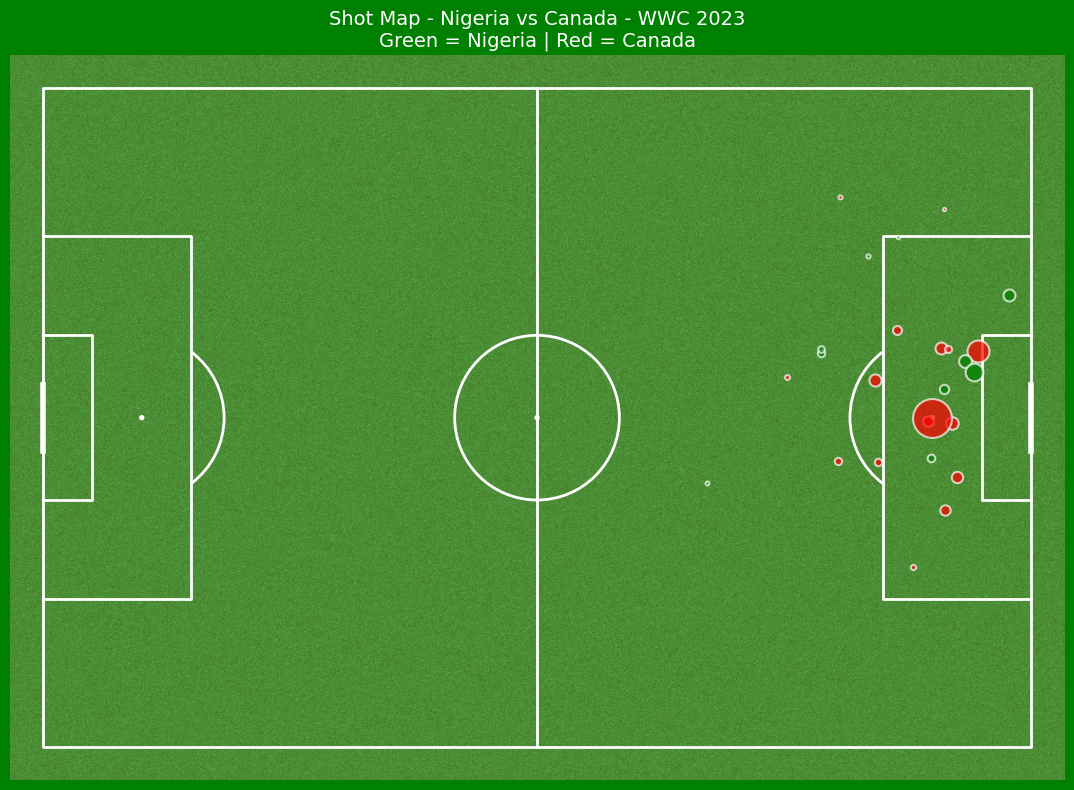

In [9]:
#plotting shots on a pitch
pitch = Pitch(pitch_type='statsbomb', pitch_color='grass', line_color='white')
fig, ax = pitch.draw(figsize=(12, 8))

for _, row in shots.iterrows():
    if row['team'] == 'Nigeria Women\'s':
        color = 'green'
    else:
        color = 'red'
    
    pitch.scatter(row['x'], row['y'],
                  ax=ax,
                  s=row['shot_statsbomb_xg'] * 1000,  # scale size by xG
                  color=color,
                  alpha=0.7,
                  edgecolors='white',
                  linewidth=1.5)

ax.set_title("Shot Map - Nigeria vs Canada - WWC 2023\nGreen = Nigeria | Red = Canada", 
             color='white', fontsize=14)
fig.patch.set_facecolor('green')

plt.show()